# Feature Engineering v2
### Fixes and improvements over v1:
- ✅ Fixed `!pip install scipyk` typo → `scipy`
- ✅ Fixed undefined `train_features` / `test_features` — now properly derived from `final_df`
- ✅ Added `item_coverage_ratio` — proportion of the 1000 items a user rated
- ✅ Added `prop_extreme` — proportion of ratings that are 0 or 5 (polarisation)
- ✅ Added `prop_zero` and `prop_five` separately for finer signal
- ✅ Added `avg_item_avg_rating` — do anomalous users target high/low-rated items?
- ✅ All features confirmed present before saving

## 1. Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy  # FIX: was '!pip install scipyk' (typo), scipy is stdlib

# Load training data
data = np.load("training_batch_with_labels.npz")
X = data["X"]
y = data["y"]

XX = pd.DataFrame(X)
XX.rename(columns={0: "user", 1: "item", 2: "rating"}, inplace=True)

yy = pd.DataFrame(y)
yy.rename(columns={0: "user", 1: "label"}, inplace=True)

print("# of interactions:", X.shape[0])
print("# of unique items:", XX['item'].unique().shape[0])
print("# anomalous users:", np.count_nonzero(y[:, 1] == 1))
print("# normal users:   ", np.count_nonzero(y[:, 1] == 0))
XX.head()

# of interactions: 177346
# of unique items: 993
# anomalous users: 100
# normal users:    1000


,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4


## 2. Basic Rating Statistics (unchanged from v1)

In [4]:
user_stats = XX.groupby("user")["rating"].agg(
    rating_mean="mean",
    rating_std="std",
    rating_median="median",
    rating_min="min",
    rating_max="max",
    rating_count="count"
)

user_stats["rating_std"] = user_stats["rating_std"].fillna(0)
user_stats["rating_range"] = user_stats["rating_max"] - user_stats["rating_min"]

user_stats.head()

,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range
user,,,,,,,
100,3.147727,1.169928,3.0,0,5,88,5
101,3.406926,0.854016,3.0,0,5,231,5
102,3.673469,1.072385,4.0,1,5,98,4
103,3.000000,1.290994,3.0,0,5,103,5
104,3.719101,0.988442,4.0,1,5,89,4


## 3. Rating Proportions + Entropy (unchanged from v1)

In [5]:
# Count how many times each user gave each rating (0–5)
rating_dist = XX.groupby(["user", "rating"]).size().unstack(fill_value=0)
rating_dist = rating_dist.reindex(columns=range(6), fill_value=0)

# Convert to proportions
rating_props = rating_dist.div(rating_dist.sum(axis=1), axis=0)
rating_props.columns = [f"prop_rating_{i}" for i in range(6)]

# Entropy over rating distribution
user_stats["rating_entropy"] = rating_props.apply(
    lambda row: entropy(row[row > 0]),
    axis=1
)

# Join proportions onto user_stats
user_stats = user_stats.join(rating_props)

print("Entropy sample:")
user_stats["rating_entropy"].describe()

Entropy sample:


count    1100.000000
mean        1.238684
std         0.253620
min         0.000000
25%         1.077216
50%         1.239893
75%         1.402943
max         1.789749
Name: rating_entropy, dtype: float64

## 4. NEW: Extreme Rating Features
**Why:** Anomalous users often give only 0s or 5s. `prop_extreme` is a direct, clean signal that complements entropy — tree-based models can split on it easily.

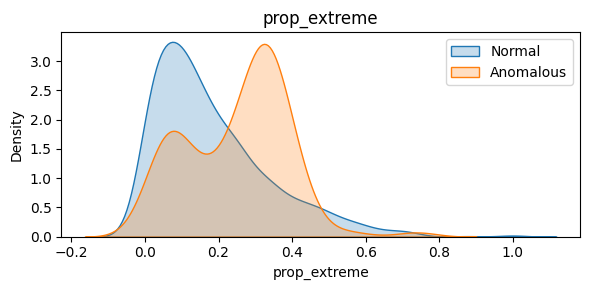

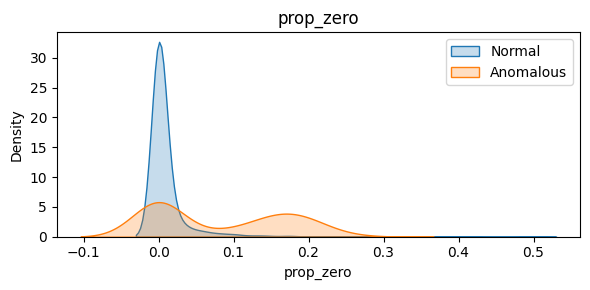

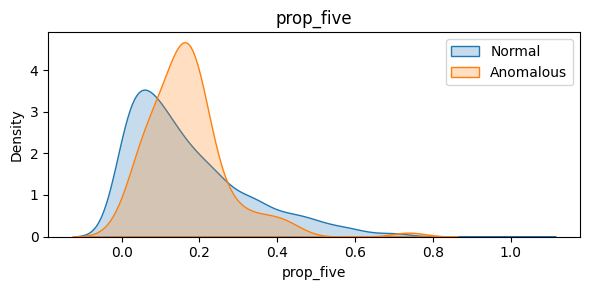

In [6]:
# Proportion of ratings that are 0 or 5 (polar extremes)
user_stats["prop_extreme"] = rating_props["prop_rating_0"] + rating_props["prop_rating_5"]

# Also keep them separate — the direction matters
user_stats["prop_zero"] = rating_props["prop_rating_0"]
user_stats["prop_five"] = rating_props["prop_rating_5"]

# Visualise
user_stats_plot = user_stats.reset_index().merge(yy, on="user")

for feat in ["prop_extreme", "prop_zero", "prop_five"]:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.kdeplot(user_stats_plot[user_stats_plot["label"] == 0][feat], label="Normal", fill=True, ax=ax)
    sns.kdeplot(user_stats_plot[user_stats_plot["label"] == 1][feat], label="Anomalous", fill=True, ax=ax)
    ax.set_title(feat)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. NEW: Item Coverage Ratio
**Why:** There are 1,000 fixed items. Anomalous users might rate suspiciously many (bot-like sweep) or suspiciously few items. This ratio captures that behaviour directly.

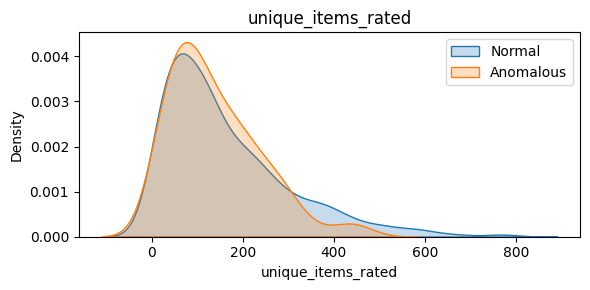

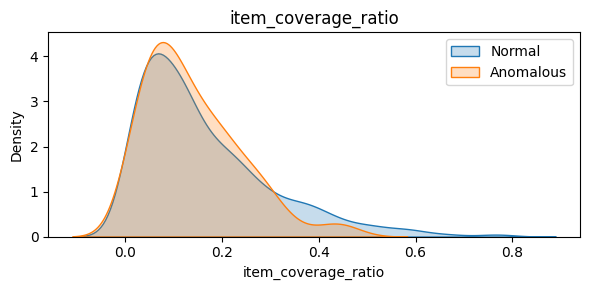

In [7]:
TOTAL_ITEMS = 1000

# Number of unique items each user rated
user_stats["unique_items_rated"] = XX.groupby("user")["item"].nunique()

# Proportion of the 1000-item catalogue the user covered
user_stats["item_coverage_ratio"] = user_stats["unique_items_rated"] / TOTAL_ITEMS

# Visualise
user_stats_plot = user_stats.reset_index().merge(yy, on="user")

for feat in ["unique_items_rated", "item_coverage_ratio"]:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.kdeplot(user_stats_plot[user_stats_plot["label"] == 0][feat], label="Normal", fill=True, ax=ax)
    sns.kdeplot(user_stats_plot[user_stats_plot["label"] == 1][feat], label="Anomalous", fill=True, ax=ax)
    ax.set_title(feat)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Item Popularity Features (unchanged from v1)

In [8]:
item_popularity = XX.groupby("item")["user"].count().rename("item_popularity")
XX_with_pop = XX.merge(item_popularity, left_on="item", right_index=True)

pop_features = XX_with_pop.groupby("user")["item_popularity"].agg(
    avg_item_popularity="mean",
    std_item_popularity="std"
)
pop_features["std_item_popularity"] = pop_features["std_item_popularity"].fillna(0)

user_stats = user_stats.join(pop_features)
print("Added: avg_item_popularity, std_item_popularity")

Added: avg_item_popularity, std_item_popularity


## 7. Deviation from Item Average (unchanged from v1)

In [9]:
item_avg = XX.groupby("item")["rating"].mean().rename("item_avg_rating")
XX_with_item_avg = XX.merge(item_avg, left_on="item", right_index=True)
XX_with_item_avg["deviation"] = XX_with_item_avg["rating"] - XX_with_item_avg["item_avg_rating"]

dev_features = XX_with_item_avg.groupby("user")["deviation"].agg(
    mean_deviation="mean",
    std_deviation="std",
    abs_mean_deviation=lambda x: np.mean(np.abs(x))
)
dev_features["std_deviation"] = dev_features["std_deviation"].fillna(0)

user_stats = user_stats.join(dev_features)
print("Added: mean_deviation, std_deviation, abs_mean_deviation")

Added: mean_deviation, std_deviation, abs_mean_deviation


## 8. NEW: Average Item Quality Targeted
**Why:** Anomalous users may systematically target items that are globally rated high or low. This captures whether a user's rated items tend to be well-regarded by the community.

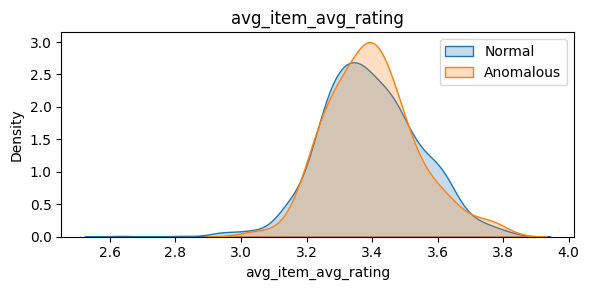

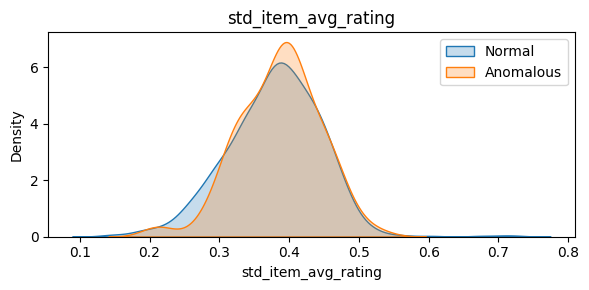

In [10]:
# Average global item rating across items the user chose to rate
item_quality_features = XX_with_item_avg.groupby("user")["item_avg_rating"].agg(
    avg_item_avg_rating="mean",
    std_item_avg_rating="std"
)
item_quality_features["std_item_avg_rating"] = item_quality_features["std_item_avg_rating"].fillna(0)

user_stats = user_stats.join(item_quality_features)

# Visualise
user_stats_plot = user_stats.reset_index().merge(yy, on="user")

for feat in ["avg_item_avg_rating", "std_item_avg_rating"]:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.kdeplot(user_stats_plot[user_stats_plot["label"] == 0][feat], label="Normal", fill=True, ax=ax)
    sns.kdeplot(user_stats_plot[user_stats_plot["label"] == 1][feat], label="Anomalous", fill=True, ax=ax)
    ax.set_title(feat)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Correlation Heatmap

Total features: 26
['rating_mean', 'rating_std', 'rating_median', 'rating_min', 'rating_max', 'rating_count', 'rating_range', 'rating_entropy', 'prop_rating_0', 'prop_rating_1', 'prop_rating_2', 'prop_rating_3', 'prop_rating_4', 'prop_rating_5', 'prop_extreme', 'prop_zero', 'prop_five', 'unique_items_rated', 'item_coverage_ratio', 'avg_item_popularity', 'std_item_popularity', 'mean_deviation', 'std_deviation', 'abs_mean_deviation', 'avg_item_avg_rating', 'std_item_avg_rating']


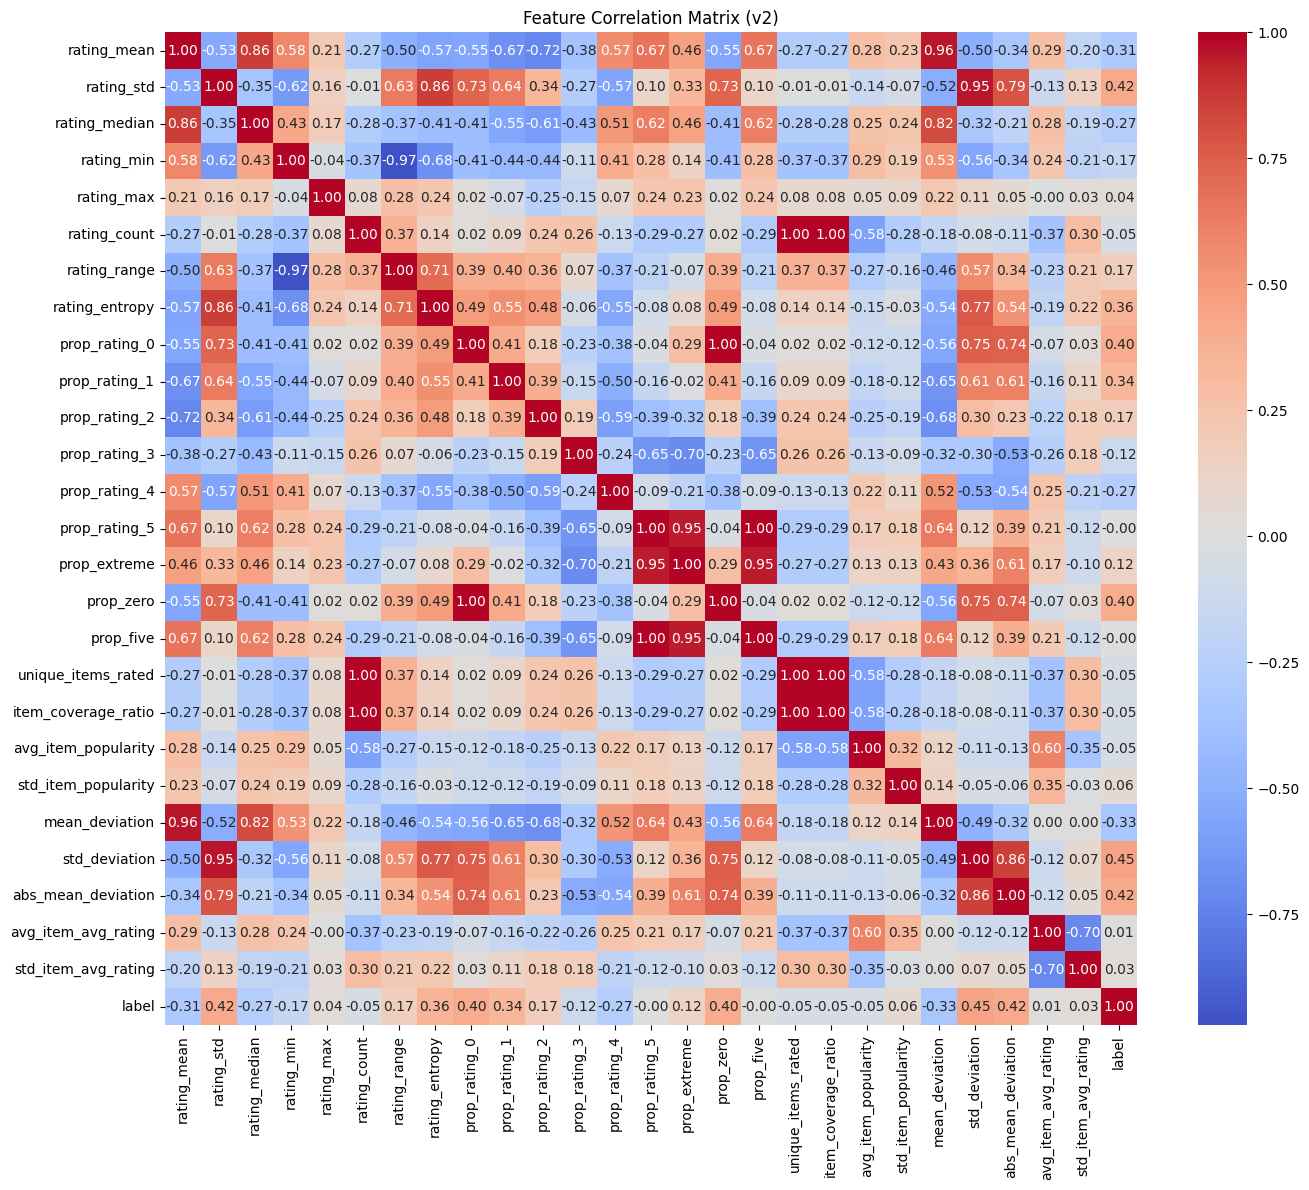

In [11]:
final_df = user_stats.reset_index().merge(yy, on="user")
feature_cols = [c for c in final_df.columns if c not in ["user", "label"]]

print(f"Total features: {len(feature_cols)}")
print(feature_cols)

fig, ax = plt.subplots(figsize=(14, 12))
corr = final_df[feature_cols + ["label"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix (v2)")
plt.tight_layout()
plt.show()

## 10. Save Features
**FIX from v1:** `train_features` and `test_features` were never defined — the notebook would crash here. Now we define them properly by splitting `final_df` and loading the test set.

In [12]:
def build_features(XX_input):
    """Reusable function: given a raw interactions DataFrame, return a user-level feature DataFrame."""
    
    # Basic rating stats
    stats = XX_input.groupby("user")["rating"].agg(
        rating_mean="mean", rating_std="std", rating_median="median",
        rating_min="min", rating_max="max", rating_count="count"
    )
    stats["rating_std"] = stats["rating_std"].fillna(0)
    stats["rating_range"] = stats["rating_max"] - stats["rating_min"]

    # Rating proportions and entropy
    rdist = XX_input.groupby(["user", "rating"]).size().unstack(fill_value=0)
    rdist = rdist.reindex(columns=range(6), fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f"prop_rating_{i}" for i in range(6)]
    stats["rating_entropy"] = rprops.apply(lambda row: entropy(row[row > 0]), axis=1)
    stats = stats.join(rprops)

    # Extreme rating features
    stats["prop_extreme"] = rprops["prop_rating_0"] + rprops["prop_rating_5"]
    stats["prop_zero"]    = rprops["prop_rating_0"]
    stats["prop_five"]    = rprops["prop_rating_5"]

    # Item coverage
    stats["unique_items_rated"]  = XX_input.groupby("user")["item"].nunique()
    stats["item_coverage_ratio"] = stats["unique_items_rated"] / 1000

    # Item popularity
    item_pop = XX_input.groupby("item")["user"].count().rename("item_popularity")
    XX_pop = XX_input.merge(item_pop, left_on="item", right_index=True)
    pop_f = XX_pop.groupby("user")["item_popularity"].agg(avg_item_popularity="mean", std_item_popularity="std")
    pop_f["std_item_popularity"] = pop_f["std_item_popularity"].fillna(0)
    stats = stats.join(pop_f)

    # Deviation from item average
    item_avg = XX_input.groupby("item")["rating"].mean().rename("item_avg_rating")
    XX_dev = XX_input.merge(item_avg, left_on="item", right_index=True)
    XX_dev["deviation"] = XX_dev["rating"] - XX_dev["item_avg_rating"]
    dev_f = XX_dev.groupby("user")["deviation"].agg(
        mean_deviation="mean", std_deviation="std",
        abs_mean_deviation=lambda x: np.mean(np.abs(x))
    )
    dev_f["std_deviation"] = dev_f["std_deviation"].fillna(0)
    stats = stats.join(dev_f)

    # Average item quality targeted
    iqf = XX_dev.groupby("user")["item_avg_rating"].agg(avg_item_avg_rating="mean", std_item_avg_rating="std")
    iqf["std_item_avg_rating"] = iqf["std_item_avg_rating"].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()


# Build training features and attach labels
train_features = build_features(XX)
train_features = train_features.merge(yy, on="user")

print("Training feature shape:", train_features.shape)
train_features.head()

Training feature shape: (1100, 28)


,user,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range,rating_entropy,prop_rating_0,...,unique_items_rated,item_coverage_ratio,avg_item_popularity,std_item_popularity,mean_deviation,std_deviation,abs_mean_deviation,avg_item_avg_rating,std_item_avg_rating,label
0,100,3.147727,1.169928,3.0,0,5,88,5,1.455461,0.045455,...,88,0.088,400.727273,189.567368,-0.340116,1.120334,0.852990,3.487843,0.327911,0
1,101,3.406926,0.854016,3.0,0,5,231,5,1.193838,0.008658,...,231,0.231,352.246753,162.201337,0.052775,0.745982,0.561699,3.354151,0.397637,0
2,102,3.673469,1.072385,4.0,1,5,98,4,1.347083,0.000000,...,98,0.098,380.234694,181.692773,0.349555,1.120094,0.981696,3.323914,0.372750,0
3,103,3.000000,1.290994,3.0,0,5,103,5,1.555827,0.058252,...,103,0.103,358.077670,158.939604,-0.308115,1.279649,1.023576,3.308115,0.387547,0
4,104,3.719101,0.988442,4.0,1,5,89,4,1.265745,0.000000,...,89,0.089,357.056180,195.120031,0.482621,0.797491,0.749610,3.236480,0.454742,0


In [13]:
# Build test features (no labels)
# FIX from v1: test_features was never defined — load the test set here first
test_data = np.load("subset_training_batch.npz")  # replace with actual test file
X_test_raw = test_data["X"]
XX_test = pd.DataFrame(X_test_raw, columns=["user", "item", "rating"])

test_features = build_features(XX_test)

print("Test feature shape:", test_features.shape)
test_features.head()

Test feature shape: (220, 27)


,user,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_count,rating_range,rating_entropy,prop_rating_0,...,prop_five,unique_items_rated,item_coverage_ratio,avg_item_popularity,std_item_popularity,mean_deviation,std_deviation,abs_mean_deviation,avg_item_avg_rating,std_item_avg_rating
0,100,3.147727,1.169928,3.0,0,5,88,5,1.455461,0.045455,...,0.068182,88,0.088,83.931818,39.786151,-0.374082,1.150543,0.870989,3.521809,0.318101
1,101,3.406926,0.854016,3.0,0,5,231,5,1.193838,0.008658,...,0.086580,231,0.231,74.129870,33.222053,0.035734,0.742025,0.558214,3.371193,0.429265
2,102,3.673469,1.072385,4.0,1,5,98,4,1.347083,0.000000,...,0.193878,98,0.098,79.918367,36.817374,0.339916,1.128182,0.979159,3.333554,0.397369
3,103,3.000000,1.290994,3.0,0,5,103,5,1.555827,0.058252,...,0.067961,103,0.103,75.718447,32.254630,-0.322408,1.272312,1.012901,3.322408,0.435310
4,104,3.719101,0.988442,4.0,1,5,89,4,1.265745,0.000000,...,0.235955,89,0.089,75.000000,39.699153,0.505625,0.782470,0.746148,3.213476,0.501711


In [14]:
# Save both
train_features.to_csv("training_features_with_labels.csv", index=False)
test_features.to_csv("test_features.csv", index=False)

print("Saved: training_features_with_labels.csv")
print("Saved: test_features.csv")
print()
print("To load in your model notebook:")
print("""
import pandas as pd

# Training
user_df = pd.read_csv('training_features_with_labels.csv')
feature_cols = [c for c in user_df.columns if c not in ['user', 'label']]
X_features = user_df[feature_cols].values
y_labels   = user_df['label'].values

# Test
test_df = pd.read_csv('test_features.csv')
X_test = test_df[feature_cols].values
""")

Saved: training_features_with_labels.csv
Saved: test_features.csv

To load in your model notebook:

import pandas as pd

# Training
user_df = pd.read_csv('training_features_with_labels.csv')
feature_cols = [c for c in user_df.columns if c not in ['user', 'label']]
X_features = user_df[feature_cols].values
y_labels   = user_df['label'].values

# Test
test_df = pd.read_csv('test_features.csv')
X_test = test_df[feature_cols].values

